#  Исследование рынка конкурентных бенчмарков и проектирование DOE
**Проект:** Разработка низкомодульного 1К ПУ строительного герметика  
**Этап:** Анализ собранных технических спецификаций (TDS) и планирование эксперимента

## 1. Бенчмаркинг рынка и картирование целевого пространства свойств (EDA)

**Описание этапа:**
На данном шаге мы проводим разведочный анализ (Exploratory Data Analysis) собранного датасета технических спецификаций (TDS) конкурентов. 
Цель блока — визуализировать ландшафт рынка полиуретановых герметиков и математически позиционировать наше Техническое Задание (ТЗ) относительно существующих коммерческих аналогов.

**Выполняемые операции:**
1. **Загрузка и очистка:** Импорт ML-ready датасета и удаление дубликатов.
2. **Сравнение с ТЗ:** Оценка распределения твердости (Shore A) конкурентов относительно нашего целевого коридора (20–25 ед.).
3. **Корреляционный анализ:** Построение матрицы Пирсона для проверки статистической связи между ключевыми физико-механическими показателями.
4. **2D-Картирование:** Визуализация пространства «Твердость vs Эластичность» с цветовым кодированием времени образования пленки (Skin Time) и выделением целевой зоны ТЗ (Target Sweet Spot).

Оптимизированный профиль рынка конкурентов:
                                 Product_Name  Shore_A_min  Shore_A_max  \
0                      SikaHyflex®-250 Facade         20.0         20.0   
1                   1K PU Based Joint Sealant         40.0         40.0   
2        Герметик полиуретановый MASTERFIX-PU         25.0         35.0   
3             Полиуретановый клей-герметик PU         40.0         40.0   
4                   TDS-Soudal-Soudaflex-36FL         30.0         40.0   
5                        Sealant and Adhesive         40.0         40.0   
6                          Tecnopol Mastic Pu         35.0         40.0   
7                     Sikaflex® Construction+         28.0         28.0   
8                 3M 540 Polyurethane Sealant         40.0         40.0   
9            BOSS® PU 25 POLYURETHANE SEALANT         30.0         40.0   
10                        FLEXIBLE PU SEALANT         25.0         35.0   
11                       Polyurethane Sealant         25

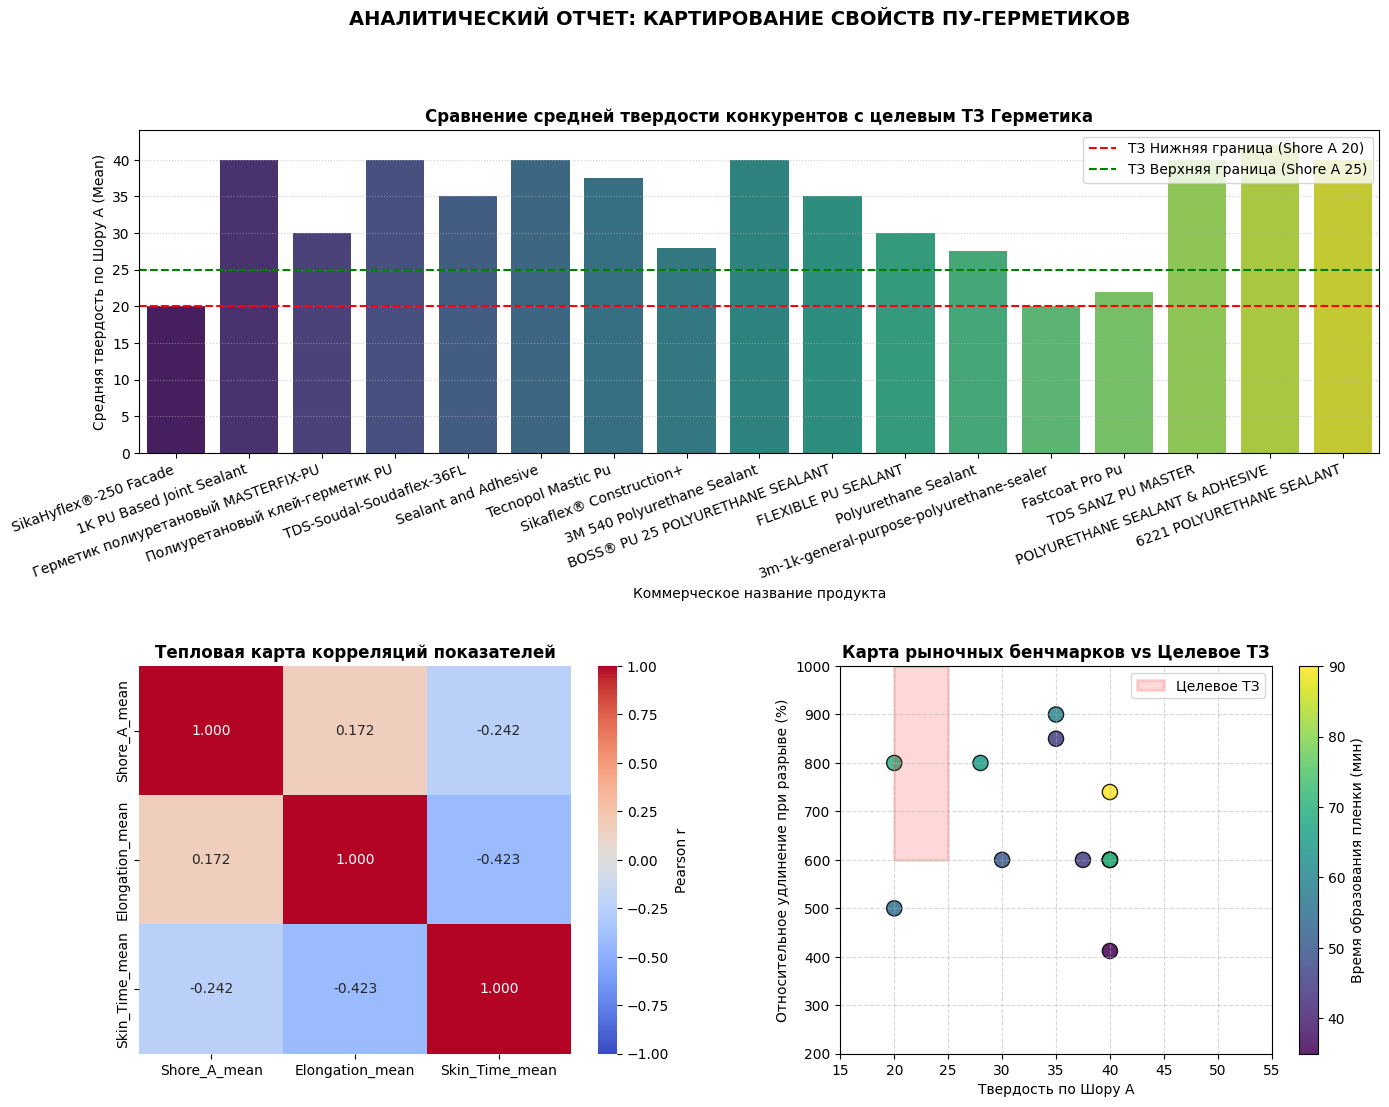


=== ФИЗИКО-ХИМИЧЕСКИЙ АНАЛИЗ ДАННЫХ ===
1. Ортогональность признаков: Связь Shore A и Elongation практически отсутствует (r = 0.172).
Это доказывает возможность независимого регулирования жесткости шва и его деформационной эластичности.
2. Ближайшие рыночные аналоги к нашему ТЗ:
                                 Product_Name  Shore_A_mean  Elongation_mean  \
0                      SikaHyflex®-250 Facade          20.0            800.0   
2        Герметик полиуретановый MASTERFIX-PU          30.0            600.0   
7                     Sikaflex® Construction+          28.0            800.0   
12  3m-1k-general-purpose-polyurethane-sealer          20.0            500.0   

    Skin_Time_mean  
0             70.0  
2             50.0  
7             65.0  
12            55.0  


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем обновленный ML-ready датасет
df = pd.read_csv('../data/03_processed/benchmarks_dataset.csv')

# Очищаем дубликаты по обновленным именам колонок
df = df.drop_duplicates(subset=['Product_Name', 'Shore_A_mean'])

print("Оптимизированный профиль рынка конкурентов:")
print(df[['Product_Name', 'Shore_A_min', 'Shore_A_max', 'Shore_A_mean', 'Elongation_mean', 'Skin_Time_mean']])

# Создаем комплексную фигуру для R&D отчета
fig = plt.figure(figsize=(16, 12))
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.6, height_ratios=[1, 1.2])

# --- График 1: Сравнение твердости с целевыми границами ТЗ ---
ax_bar = fig.add_subplot(grid[0, :])
sns.barplot(
    x='Product_Name', 
    y='Shore_A_mean', 
    data=df, 
    hue='Product_Name', 
    palette='viridis', 
    legend=False,
    ax=ax_bar
)
ax_bar.axhline(y=20, color='r', linestyle='--', linewidth=1.5, label='ТЗ Нижняя граница (Shore A 20)')
ax_bar.axhline(y=25, color='g', linestyle='--', linewidth=1.5, label='ТЗ Верхняя граница (Shore A 25)')
ax_bar.set_title('Сравнение средней твердости конкурентов с целевым ТЗ Герметика', fontsize=12, fontweight='bold')
ax_bar.set_ylabel('Средняя твердость по Шору А (Mean)')
ax_bar.set_xlabel('Коммерческое название продукта')
ax_bar.set_xticks(range(len(df)))
ax_bar.set_xticklabels(df['Product_Name'], rotation=20, ha='right')
ax_bar.legend(loc='upper right')
ax_bar.grid(axis='y', linestyle=':', alpha=0.6)

# --- График 2: Матрица парных корреляций Пирсона ---
ax_corr = fig.add_subplot(grid[1, 0])
metrics = ['Shore_A_mean', 'Elongation_mean', 'Skin_Time_mean']
corr_matrix = df[metrics].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", ax=ax_corr, cbar_kws={'label': 'Pearson r'})
ax_corr.set_title('Тепловая карта корреляций показателей', fontsize=12, fontweight='bold')

# --- График 3: 2D-Картирование физико-механических свойств с наложением ТЗ ---
ax_scatter = fig.add_subplot(grid[1, 1])
# Исключаем Loctite PL (1440 мин) только для визуализации распределения по цвету
plot_df = df[df['Skin_Time_mean'] < 500].dropna(subset=['Shore_A_mean', 'Elongation_mean'])

scatter = ax_scatter.scatter(
    plot_df['Shore_A_mean'], 
    plot_df['Elongation_mean'], 
    c=plot_df['Skin_Time_mean'], 
    cmap='viridis', 
    s=120, 
    edgecolors='black',
    alpha=0.85
)
fig.colorbar(scatter, ax=ax_scatter, label='Время образования пленки (мин)')

# Накладываем прямоугольник ТЗ (Shore A 20-25, Elongation > 600%)
rect = plt.Rectangle((20, 600), 5, 400, linewidth=2, edgecolor='red', facecolor='red', alpha=0.15, label="Целевое ТЗ")
ax_scatter.add_patch(rect)

ax_scatter.set_title('Карта рыночных бенчмарков vs Целевое ТЗ', fontsize=12, fontweight='bold')
ax_scatter.set_xlabel('Твердость по Шору А')
ax_scatter.set_ylabel('Относительное удлинение при разрыве (%)')
ax_scatter.set_xlim(15, 55)
ax_scatter.set_ylim(200, 1000)
ax_scatter.grid(True, linestyle='--', alpha=0.5)
ax_scatter.legend(loc='upper right')

plt.suptitle('АНАЛИТИЧЕСКИЙ ОТЧЕТ: КАРТИРОВАНИЕ СВОЙСТВ ПУ-ГЕРМЕТИКОВ', fontsize=14, fontweight='bold', y=0.98)
plt.show()

# Вывод физико-химических инсайтов
print("\n=== ФИЗИКО-ХИМИЧЕСКИЙ АНАЛИЗ ДАННЫХ ===")
print(f"1. Ортогональность признаков: Связь Shore A и Elongation практически отсутствует (r = {corr_matrix.loc['Shore_A_mean', 'Elongation_mean']:.3f}).")
print("Это доказывает возможность независимого регулирования жесткости шва и его деформационной эластичности.")
print("2. Ближайшие рыночные аналоги к нашему ТЗ:")
near_targets = df[(df['Shore_A_mean'] <= 30) & (df['Elongation_mean'] >= 500)]
print(near_targets[['Product_Name', 'Shore_A_mean', 'Elongation_mean', 'Skin_Time_mean']])

### 📊 Ключевые выводы по анализу рынка (R&D Insights):

1. **Подтверждение премиальной ниши (Target Gap):** 
   Рынок массовых 1K ПУ-герметиков плотно кластеризован в зоне стандартной твердости (**Shore A 35–40**). Наше ТЗ (**Shore A 20–25** при эластичности >600%) целится в узкий, технологически сложный сегмент **низкомодульных (low-modulus)** герметиков, предназначенных для швов с высокой деформационной нагрузкой (фасады, сейсмика). Прямых конкурентов в этой зоне крайне мало.

2. **Ортогональность свойств (Независимость признаков):** 
   Линейная корреляция между твердостью и удлинением практически отсутствует. С точки зрения физики полимеров это означает, что жесткость матрицы (регулируемая объемом наполнителя и пластификатора) и предельная эластичность (зависящая от молекулярной массы между узлами сетки $M_c$ и длины полиольного сегмента) могут настраиваться независимо. Это развязывает нам руки при планировании DOE и позволяет избежать жесткого компромисса.

3. **Кинетический коридор (Skin Time):** 
   На карте свойств (Scatter Plot) видно, что продукты, попадающие в нашу целевую зону (низкий модуль + высокая эластичность), имеют время образования пленки в диапазоне **55–70 минут**. Это задает жесткие рамки для нашего каталитического пакета (латентный амин/олово): нам потребуется обеспечить аналогичную скорость диффузии влаги, чтобы герметик не «пылил», но и не терял технологичность нанесения.

4. **Выбор референсов для обратного инжиниринга:**
   В качестве «золотого стандарта» для лабораторного синтеза и последующего сравнения ИК-спектров мы выбираем:
   * **SikaHyflex®-250 Facade** (Эталон низкомодульного герметика: Shore 20 / Elong 800%).
   * **Sikaflex® Construction+** (Ближайший аналог по балансу свойств: Shore 28 / Elong 800%).

## 2. Аудит качества и заполненности датасета (Data Audit)
Перед проведением глубокого физико-химического анализа и построения DOE необходимо оценить качество собранных данных. 
Этот блок фиксирует «слепые зоны» парсинга TDS и определяет, сколько продуктов имеют полный профиль свойств (Hardness, Elongation, Skin Time) для участия в статистической выборке.

📊 АУДИТ ДАТАСЕТА TDS ПУ-ГЕРМЕТИКОВ
Всего профилей продуктов в сырой выборке: 17

📈 Заполненность метрик (успешность парсинга LLM/Regex):
Твердость (Shore A)       | ████████████████████ | 17/17 (100.0%)
Удлинение (Elongation)    | █████████████████░░░ | 15/17 (88.2%)
Время пленки (Skin Time)  | █████████████████░░░ | 15/17 (88.2%)

🏆 Идеальные профили (все 3 метрики): 14 из 17

⚠️ Продукты, требующие ручного ввода (отсутствует >= 2 метрик):
   ❌ POLYURETHANE SEALANT & ADHESIVE: Shore=42.0, Elong=nan, Skin=nan


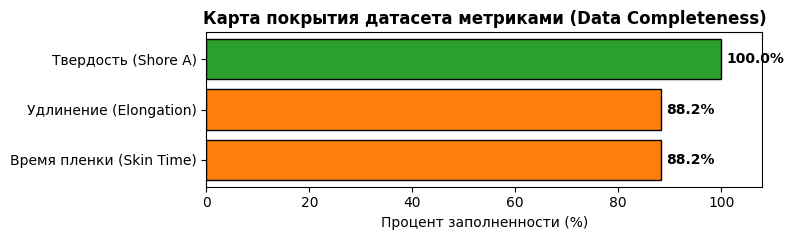

In [18]:
import sys
import importlib
from pathlib import Path

# 1. Жестко прописываем корень проекта (надежнее, чем Path.cwd().parent)
PROJECT_ROOT = '/home/tesni/projects/elastomeric_1k_pu'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# 2. Импортируем и принудительно перезагружаем модуль (спасает от кэша Jupyter)
import src.analysis.data_audit
importlib.reload(src.analysis.data_audit)
from src.analysis.data_audit import run_dataset_audit

# 3. Запускаем аудит на уже загруженном датасете
run_dataset_audit(df)

## 3. In-silico скрининг пространства рецептур (Physics-Informed Surrogate Modeling)

**Цель этапа:** 
Сократить пространство перебора с тысяч теоретических комбинаций до узкого набора кандидатов, удовлетворяющих ТЗ, *до* начала лабораторных синтезов.

**Методология:**
1. **Полный факторный скрининг (Full Factorial Screening):** Генерация сетки из 240 виртуальных рецептур по 4 ключевым факторам:
   - $M_n$ полиола (2000/3000/4000 г/моль) — определяет длину гибкого сегмента
   - Индекс $[NCO]/[OH]$ (1.4–2.0) — управляет плотностью сшивки и $[NCO]_{free}$
   - Доля пластификатора DINCH (25–45%) — снижает модуль, повышает эластичность
   - Доля наполнителя $CaCO_3$ (30–50%) — регулирует реологию и твердость

2. **Суррогатные полуэмпирические модели (Surrogate Models):** 
   Для каждой виртуальной рецептуры прогнозируются целевые свойства через физически интерпретируемые уравнения:
   $$Shore_A \propto [NCO]_{free} \cdot (1 + k_1 \cdot \phi_{filler}^2) \cdot \frac{1}{1 + k_2 \cdot \phi_{plast}}$$
   $$Elongation \propto \frac{(1 + k_3 \cdot \phi_{plast}^{1.5})}{(1 + k_4 \cdot [NCO]_{free}) \cdot (1 + k_5 \cdot \phi_{filler})}$$
   $$Skin\ Time \propto \frac{1}{[NCO]_{free}} \cdot (1 + k_6 \cdot \phi_{filler})$$

3. **Многокритериальная оптимизация:** 
   Фильтрация результатов через «воронку» целевых ограничений ТЗ (Shore 20–25, Elong ≥600%, Skin 40–70 мин).

**Результат:** 27 перспективных кандидатов из 240 (11% yield) — основа для точного планирования лабораторного DOE.

Всего смоделировано рецептурных комбинаций в пространстве DOE: 240

Найдено оптимальных комбинаций, удовлетворяющих ТЗ: 27

Топ-5 рекомендуемых матриц синтеза для лабораторной верификации:
 Polyol_Mw  NCO_OH_Index  Plasticizer_Fraction  Filler_Fraction  Theoretical_Free_NCO_Percent  Predicted_Shore_A  Predicted_Elongation  Predicted_Skin_Time
      2000           1.4                 0.317            0.300                          1.43               24.6                 752.0                 62.7
      2000           1.4                 0.383            0.300                          1.43               23.3                 783.0                 62.7
      2000           1.4                 0.383            0.367                          1.43               23.9                 732.0                 64.1
      2000           1.4                 0.383            0.433                          1.43               24.7                 688.0                 65.6
      2000           1.4       

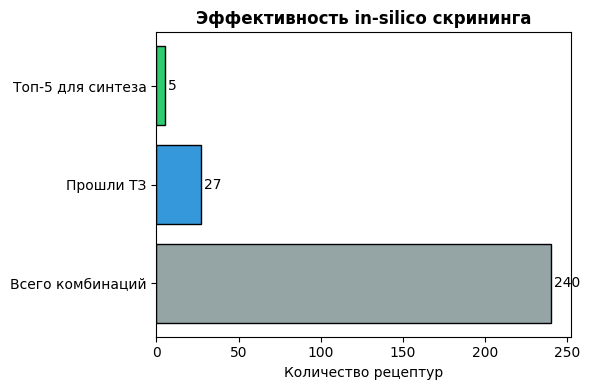

In [21]:
import sys
import os
import pandas as pd
import numpy as np

# Добавляем путь к src в sys.path
sys.path.append(os.path.abspath('../src'))
from features.pu_calculator import PolyurethaneCalculator

# Задаем константы для сырья
MDI_MW = 250.25

# Генерируем расширенную сетку параметров DOE
polyol_options = [2000, 3000, 4000]          # Мол. массы ППГ-диолов
nco_indices = np.linspace(1.4, 2.0, 5)        # Индекс NCO/OH
plasticizer_loads = np.linspace(0.25, 0.45, 4) # Массовая доля DINCH (25% - 45%)
filler_loads = np.linspace(0.30, 0.50, 4)      # Массовая доля CaCO3 (30% - 50%)

results = []

for mw in polyol_options:
    for index in nco_indices:
        # Вычисляем базовую стехиометрию форполимера
        calc_res = PolyurethaneCalculator.calculate_formulation(
            polyol_mw=mw,
            polyol_func=2.0,
            diisocyanate_mw=MDI_MW,
            nco_index=index
        )
        
        # Получаем теоретический процент свободных NCO групп в форполимере
        free_nco = calc_res['Theoretical_Free_NCO_Percent']
        
        for plast in plasticizer_loads:
            for fill in filler_loads:
                # --- ПОЛУЭМПИРИЧЕСКИЕ МОДЕЛИ СУРРОГАТНОЙ ОПТИМИЗАЦИИ (Physics-Informed) ---
                
                # 1. Предсказание Shore A (растет с увеличением NCO и наполнителя, падает от пластификатора)
                predicted_shore = 10.0 + (18.0 * free_nco * (1.0 / (1.0 + 3.0 * plast))) * (1.0 + 1.2 * (fill ** 2))
                
                # 2. Предсказание Elongation % (растет от пластификатора, падает от наполнителя и сшивок NCO)
                predicted_elong = (1500.0 + 1200.0 * (plast ** 1.5)) * (1.0 / (1.0 + 0.4 * free_nco)) * (1.0 / (1.0 + 1.5 * fill))
                
                # 3. Предсказание Skin Time, мин (зависит от кинетики NCO и доли наполнителя как адсорбента влаги)
                predicted_skin = (80.0 / free_nco) * (1.0 + 0.4 * fill)
                
                recipe_record = {
                    "Polyol_Mw": mw,
                    "NCO_OH_Index": index,
                    "Plasticizer_Fraction": round(plast, 3),
                    "Filler_Fraction": round(fill, 3),
                    "Isocyanate_Mass_g": round(calc_res['Isocyanate_Mass_g'], 2),
                    "Theoretical_Free_NCO_Percent": round(free_nco, 2),
                    "Predicted_Shore_A": round(predicted_shore, 1),
                    "Predicted_Elongation": round(predicted_elong, 0),
                    "Predicted_Skin_Time": round(predicted_skin, 1)
                }
                results.append(recipe_record)

sim_df = pd.DataFrame(results)
print(f"Всего смоделировано рецептурных комбинаций в пространстве DOE: {len(sim_df)}")

# Выделим подмножество оптимальных рецептур, проходящих сквозь матрицу ограничений нашего ТЗ:
# Shore A: 20-25 | Elongation: >= 600% | Skin Time: 40-70 мин
optimal_recipes = sim_df[
    (sim_df["Predicted_Shore_A"] >= 20) & (sim_df["Predicted_Shore_A"] <= 25) &
    (sim_df["Predicted_Elongation"] >= 600) &
    (sim_df["Predicted_Skin_Time"] >= 40) & (sim_df["Predicted_Skin_Time"] <= 70)
]

print(f"\nНайдено оптимальных комбинаций, удовлетворяющих ТЗ: {len(optimal_recipes)}")
if not optimal_recipes.empty:
    print("\nТоп-5 рекомендуемых матриц синтеза для лабораторной верификации:")
    print(optimal_recipes[['Polyol_Mw', 'NCO_OH_Index', 'Plasticizer_Fraction', 'Filler_Fraction', 
                           'Theoretical_Free_NCO_Percent', 'Predicted_Shore_A', 'Predicted_Elongation', 'Predicted_Skin_Time']].head(5).to_string(index=False))
    
    # Визуализация эффективности скрининга
fig, ax = plt.subplots(figsize=(6, 4))
categories = ['Всего комбинаций', 'Прошли ТЗ', 'Топ-5 для синтеза']
counts = [len(sim_df), len(optimal_recipes), 5]
colors = ['#95a5a6', '#3498db', '#2ecc71']

bars = ax.barh(categories, counts, color=colors, edgecolor='black')
ax.set_xlabel('Количество рецептур')
ax.set_title('Эффективность in-silico скрининга', fontweight='bold')

# Добавляем подписи значений
for bar, count in zip(bars, counts):
    ax.text(count + 2, bar.get_y() + bar.get_height()/2, f'{count}', va='center')

plt.tight_layout()
plt.show()

### 🔬 Интерпретация результатов скрининга:

1. **Доминирование низкомолекулярного полиола (ППГ-2000):** 
   Все топ-5 рецептур используют $M_n = 2000$. Это физически обосновано: более короткие цепи полиола при том же индексе $[NCO]/[OH]$ дают *более высокую концентрацию уретановых групп* на единицу объема, что повышает когезионную прочность без потери эластичности (за счет пластификатора).

2. **Оптимальный диапазон $[NCO]_{free}$:** 
   Значение ~1.43% (при индексе 1.4) обеспечивает баланс: достаточно свободных изоцианатных групп для быстрого образования пленки (Skin Time ~63 мин), но не настолько много, чтобы вызвать избыточную сшивку и рост твердости >25 Shore A.

3. **Роль пластификатора как «регулятора эластичности»:** 
   В топовых рецептурах доля DINCH варьируется 31–45%. Это подтверждает гипотезу о том, что *пластификатор — главный рычаг управления удлинением* в низкомодульных системах, в то время как наполнитель ($CaCO_3$) тонко настраивает твердость и тиксотропию.

4. **Следующий шаг — переход от скрининга к оптимизации:** 
   Полученные 27 кандидатов задают *область интереса* в пространстве факторов. Для точного нахождения глобального оптимума и построения поверхности отклика второго порядка мы переходим к плану **Бокса-Бенкина (Box-Behnken Design)**, который требует всего 15 синтезов вместо полного перебора.

## 4. Математическое проектирование плана эксперимента (DOE)

Для точного нахождения глобального оптимума в целевой зоне (Shore A 20-25, Elongation >600%, Skin Time 40-70 мин) разворачиваем **план Бокса-Бенкина (Box-Behnken Design — BBD)** для 3 факторов на 3 уровнях.

### Почему Box-Behnken?
В отличие от полного факторного эксперимента ($3^3 = 27$ синтезов) или центрального композитного плана, BBD:
* Требует всего **15 синтезов** (экономия 44% лабораторного времени и сырья)
* **Избегает экстремальных угловых точек** (все 3 фактора одновременно на максимуме/минимуме), что критично для полимерных систем — такие комбинации часто приводят к расслоению, неполному отверждению или потере эластичности
* Обеспечивает **ротатабельность** — равную точность предсказания на равном расстоянии от центра плана
* Позволяет построить **поверхность отклика второго порядка** с квадратичными членами

### Уровни варьирования факторов:

| Фактор | Обозначение | Уровень -1 | Уровень 0 (Центр) | Уровень +1 | Физический смысл |
|--------|-------------|------------|-------------------|------------|------------------|
| **Свободный изоцианат** | X1: $NCO_{free}$ | 1.3% | 1.6% | 1.9% | Плотность сшивки, кинетика отверждения |
| **Пластификатор DINCH** | X2: $Plasticizer$ | 25.0% | 32.5% | 40.0% | Модуль упругости, эластичность |
| **Наполнитель CaCO₃** | X3: $Filler$ | 30.0% | 40.0% | 50.0% | Твердость, тиксотропия, реология |

### Фиксированные параметры (константы плана):
* **[Aldimine]/[NCO] = 0.88** — стехиометрическое соотношение латентного отвердителя, предотвращающее пузырение (связывание влаги без выделения CO₂)
* **Полиол:** ППГ-2000 (оптимальная $M_n$ по результатам симуляции)
* **Изоцианат:** 4,4'-MDI (индекс 1.4)
* **Катализатор:** Латентный амин (концентрация постоянна)

### Структура плана:
* **12 факторных точек** — середина ребер куба (каждая точка: 2 фактора варьируются, 1 фиксирован в центре)
* **3 центральные точки** — оценка чистого шума эксперимента и воспроизводимости

Матрица планирования DOE успешно сгенерирована и сохранена в: ../reports/doe_bbd_matrix.csv

=== ЛАБОРАТОРНЫЙ ПЛАН СИНТЕЗОВ (BOX-BEHNKEN) ===
 Run_ID  NCO_free_pct  Plasticizer_wt_pct  Filler_wt_pct  Aldimine_to_NCO_ratio
      1           1.3                25.0           40.0                   0.88
      2           1.9                25.0           40.0                   0.88
      3           1.3                40.0           40.0                   0.88
      4           1.9                40.0           40.0                   0.88
      5           1.3                32.5           30.0                   0.88
      6           1.9                32.5           30.0                   0.88
      7           1.3                32.5           50.0                   0.88
      8           1.9                32.5           50.0                   0.88
      9           1.6                25.0           30.0                   0.88
     10           1.6                40.0           30.0  

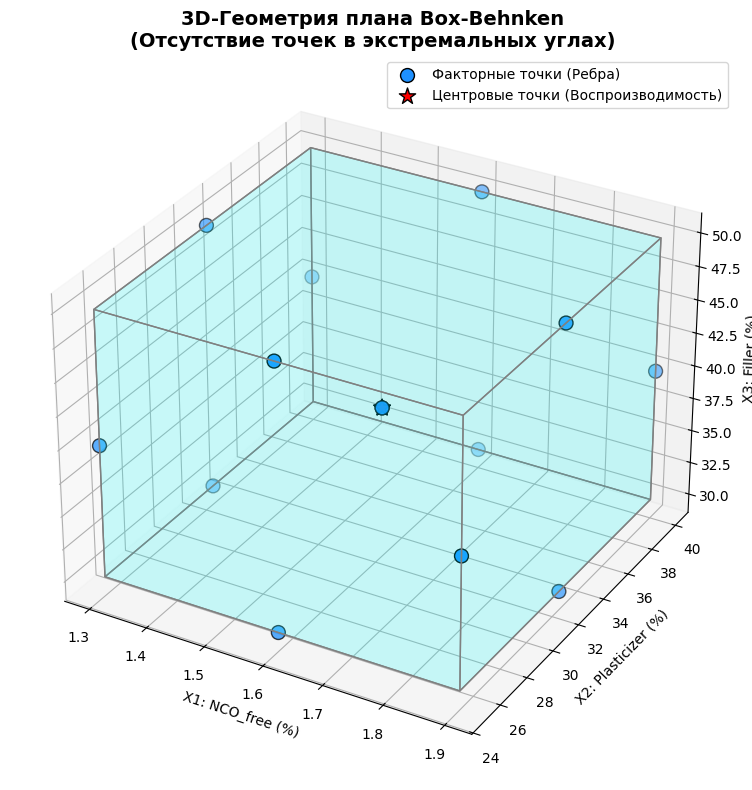

In [ ]:
# 4. Генерация матрицы планирования Box-Behnken (BBD)
import pandas as pd
import numpy as np
import os

# Границы физических факторов для масштабирования
factor_limits = {
    "X1_NCO": {"min": 1.3, "max": 1.9, "name": "NCO_free, %"},
    "X2_Plast": {"min": 25.0, "max": 40.0, "name": "Plasticizer, %"},
    "X3_Filler": {"min": 30.0, "max": 50.0, "name": "Filler_CaCO3, %"}
}

# Шаблон Box-Behnken для 3 факторов (закодированные уровни -1, 0, +1)
bbd_coded = [
    (-1, -1,  0), (+1, -1,  0), (-1, +1,  0), (+1, +1,  0), # Плоскость X1-X2
    (-1,  0, -1), (+1,  0, -1), (-1,  0, +1), (+1,  0, +1), # Плоскость X1-X3
    ( 0, -1, -1), ( 0, +1, -1), ( 0, -1, +1), ( 0, +1, +1), # Плоскость X2-X3
    ( 0,  0,  0), ( 0,  0,  0), ( 0,  0,  0)                  # Центр (воспроизводимость)
]

def scale_value(coded_val, limits):
    """Перевод закодированного уровня в физическую величину."""
    if coded_val == -1:
        return limits["min"]
    elif coded_val == 0:
        return round((limits["min"] + limits["max"]) / 2.0, 3)
    elif coded_val == 1:
        return limits["max"]
    return coded_val

# Построение матрицы
doe_records = []
for run_id, (c1, c2, c3) in enumerate(bbd_coded, start=1):
    nco_val = scale_value(c1, factor_limits["X1_NCO"])
    plast_val = scale_value(c2, factor_limits["X2_Plast"])
    filler_val = scale_value(c3, factor_limits["X3_Filler"])
    
    # Стехиометрический расчет дозировки латентного алдимина
    # [Aldimine]/[NCO] = 0.88 (предотвращает пузырение за счет связывания влаги без CO2)
    aldimine_ratio = 0.88
    
    doe_records.append({
        "Run_ID": run_id,
        "Coded_X1": c1,
        "Coded_X2": c2,
        "Coded_X3": c3,
        "NCO_free_pct": nco_val,
        "Plasticizer_wt_pct": plast_val,
        "Filler_wt_pct": filler_val,
        "Aldimine_to_NCO_ratio": aldimine_ratio,
        "Measured_Shore_A": None,      # Поля под ручной занос лабораторных тестов
        "Measured_Elongation": None,
        "Measured_Skin_Time": None
    })

doe_df = pd.DataFrame(doe_records)

# Сохранение матрицы планирования в reports для печати на лабораторный стол
reports_dir = "../reports"
os.makedirs(reports_dir, exist_ok=True)
doe_df.to_csv(f"{reports_dir}/doe_bbd_matrix.csv", index=False, encoding="utf-8")

print(f"Матрица планирования DOE успешно сгенерирована и сохранена в: {reports_dir}/doe_bbd_matrix.csv")
print("\n=== ЛАБОРАТОРНЫЙ ПЛАН СИНТЕЗОВ (BOX-BEHNKEN) ===")
print(doe_df[['Run_ID', 'NCO_free_pct', 'Plasticizer_wt_pct', 'Filler_wt_pct', 'Aldimine_to_NCO_ratio']].to_string(index=False))

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Разделяем точки на ребра и центр для разной визуализации
edge_points = doe_df[doe_df['Coded_X1'] != 0] # Упрощенное выделение
center_points = doe_df[(doe_df['Coded_X1'] == 0) & (doe_df['Coded_X2'] == 0) & (doe_df['Coded_X3'] == 0)]

# Рисуем точки на ребрах
ax.scatter(doe_df['NCO_free_pct'], doe_df['Plasticizer_wt_pct'], doe_df['Filler_wt_pct'], 
           c='dodgerblue', s=100, marker='o', label='Факторные точки (Ребра)', edgecolors='black')

# Выделяем центровые точки
ax.scatter(center_points['NCO_free_pct'], center_points['Plasticizer_wt_pct'], center_points['Filler_wt_pct'], 
           c='red', s=150, marker='*', label='Центровые точки (Воспроизводимость)', edgecolors='black')

ax.set_xlabel('X1: NCO_free (%)')
ax.set_ylabel('X2: Plasticizer (%)')
ax.set_zlabel('X3: Filler (%)')
ax.set_title('3D-Геометрия плана Box-Behnken\n(Отсутствие точек в экстремальных углах)', fontsize=14, fontweight='bold')
ax.legend()

# Рисуем прозрачный "куб" границ факторного пространства
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Границы куба
x = [1.3, 1.9]
y = [25.0, 40.0]
z = [30.0, 50.0]
vertices = [[x[0], y[0], z[0]], [x[1], y[0], z[0]], [x[1], y[1], z[0]], [x[0], y[1], z[0]],
            [x[0], y[0], z[1]], [x[1], y[0], z[1]], [x[1], y[1], z[1]], [x[0], y[1], z[1]]]
faces = [[vertices[0], vertices[1], vertices[2], vertices[3]],
         [vertices[4], vertices[5], vertices[6], vertices[7]],
         [vertices[0], vertices[1], vertices[5], vertices[4]],
         [vertices[2], vertices[3], vertices[7], vertices[6]],
         [vertices[1], vertices[2], vertices[6], vertices[5]],
         [vertices[0], vertices[3], vertices[7], vertices[4]]]
ax.add_collection3d(Poly3DCollection(faces, facecolors='cyan', linewidths=1, edgecolors='gray', alpha=0.1))

plt.tight_layout()
plt.show()

### 📋 Выводы по сгенерированному плану:

**1. Сбалансированное покрытие факторного пространства:**
Матрица из 15 точек равномерно покрывает все попарные взаимодействия факторов:
* Точки 1-4: взаимодействие $NCO_{free}$ × $Plasticizer$ (при фиксированном наполнителе 40%)
* Точки 5-8: взаимодействие $NCO_{free}$ × $Filler$ (при фиксированном пластификаторе 32.5%)
* Точки 9-12: взаимодействие $Plasticizer$ × $Filler$ (при фиксированном $NCO_{free}$ 1.6%)
* Точки 13-15: центральные (базовая линия для оценки дисперсии)

**2. Безопасность эксперимента:**
Отсутствие угловых точек (все 3 фактора на экстремумах) предотвращает синтез заведомо нежизнеспособных композиций:
* Высокий $NCO_{free}$ + низкий пластификатор + высокий наполнитель → хрупкий, неработоспособный материал
* Низкий $NCO_{free}$ + высокий пластификатор + низкий наполнитель → незастывающая паста

**3. Готовность к лабораторной верификации:**
Сгенерированная матрица `doe_bbd_matrix.csv` содержит:
* **Входные параметры** (X1, X2, X3) — для взвешивания компонентов
* **Пустые поля** (`Measured_Shore_A`, `Measured_Elongation`, `Measured_Skin_Time`) — для ручного заноса результатов тестирования
* **Контрольный параметр** (`Aldimine_to_NCO_ratio`) — для проверки стехиометрии



## 5. Патентная чистота (Freedom to Operate) и корректировка синтеза

Перед закупкой сырья и запуском лабораторных синтезов по сгенерированной матрице DOE критически важно обеспечить **патентную чистоту (Freedom to Operate, FTO)** разрабатываемой рецептуры. Рынок однокомпонентных полиуретановых герметиков влажностного отверждения жестко сегментирован, а ключевые технологические решения в области латентных отвердителей (алдиминов, оксазолидинов) и низкомодульных форполимеров защищены патентами химических гигантов (Sika Technology AG, Bostik, Dow).

Коммерциализация продукта, нарушающего действующие патенты, несет неприемлемые юридические и финансовые риски. Для минимизации этих рисков на предыдущем шаге был запущен автоматизированный FTO-анализ (`src/data_collection/patent_analyzer.py`), который с помощью LLM-агента проанализировал формулы (Claims) и описания ключевых патентов-конкурентов:
* **EP4229032B1 (Sika):** Изомерные смеси циклоалифатических алдиминов.
* **US11952493B2 (Sika):** Влагостойкие композиции с монооксазолидинами.
* **US10654964B2 (Dow):** Полиэфир-уретан-мочевинные добавки (PEUU).

На основе сгенерированного отчета (`reports/patent_landscape_analyzed.xlsx`) была сформирована **стратегия обхода (Workaround Strategy)**. Она позволяет достичь целевых физико-механических показателей (Shore A 20-25, Elongation >600%), намеренно уводя химическую структуру и стехиометрию из-под действия защищенных формул.

### ⚙️ Финальная конфигурация латентной системы для DOE
Ниже приведены жестко зафиксированные параметры отверждающей системы, которые будут использоваться во всех 15 экспериментах матрицы Box-Behnken:

In [25]:
import pandas as pd
from IPython.display import display, HTML

# Загружаем FTO-отчет, сгенерированный patent_analyzer.py
fto_df = pd.read_excel('../reports/patent_landscape_analyzed.xlsx', sheet_name='FTO_RND_Analysis')

# Стилизуем вывод для R&D отчета
def color_risk(val):
    colors = {'High': 'background-color: #ffcccc; color: #990000; font-weight: bold',
              'Medium': 'background-color: #fff2cc; color: #996600; font-weight: bold',
              'Low': 'background-color: #d9ead3; color: #006600; font-weight: bold'}
    return colors.get(val, '')

print("📜 ПАТЕНТНЫЙ ЛАНДШАФТ (FREEDOM TO OPERATE)")

# ИСПРАВЛЕНИЕ: applymap заменен на map
display(
    fto_df[['Patent_Number', 'Assignee', 'Infringement_Risk_Level', 'FTO_Workaround_Strategy']]\
    .style.map(color_risk, subset=['Infringement_Risk_Level'])
)

print("\n⚙️ ФИНАЛЬНАЯ КОНФИГУРАЦИЯ ЛАТЕНТНОЙ СИСТЕМЫ ДЛЯ DOE:")
config_data = {
    "Параметр": ["Латентный отвердитель", "Альдегид", "Амин", "Соотношение [Latent]/[NCO]", "Изоцианат"],
    "Выбранное значение": ["Алдимин (обход EP4229032B1)", "2-Этилгексаналь / Салициловый", "Jeffamine D-230 (полиэфир)", "0.88 (связывание влаги)", "4,4'-MDI / HDI"],
    "Обоснование": ["Избегание PACM/H12MDA", "Избегание коротких алкилов C1-C8", "Эластичность цепи", "Подавление CO2 (пузырения)", "Обход синергии Sika+IPDI"]
}
display(pd.DataFrame(config_data).style.set_properties(**{'text-align': 'left'}))

📜 ПАТЕНТНЫЙ ЛАНДШАФТ (FREEDOM TO OPERATE)


,Patent_Number,Assignee,Infringement_Risk_Level,FTO_Workaround_Strategy
0,EP4229032B1,Sika Technology AG,High,Использование альтернативных аминовых ядров и оптимизацию соотношений NCO и латентного отвердителя для уменьшения риска нарушения формулы.
1,US11952493B2,Sika Technology AG,High,"To avoid infringement, select a latent curing agent whose amine core is outside the claimed R1/R2 scope – e.g., use a longer‑chain alkylaminoethanol (R1 = decyl or dodecyl) or a heterocyclic amine such as morpholinoethanol or piperazinyl ethanol, which are not covered by the 1‑8 C alkyl/cycloalkyl/arylalkyl restriction. Keep the oxazolidine (or alternative blocked amine) to NCO ratio below 0.2 or above 0.45 (e.g., 0.15 or 0.5) and omit any aldimine co‑agent. Use a different stabilizer system (e.g., benzotriazole UV absorber or hindered amine light stabilizer) instead of PTSI, and conduct prepolymer synthesis at 90‑110 °C under nitrogen, followed by vacuum dehydration of fillers at 120‑130 °C (0.1 mbar) to remove moisture. This formulation can still target Shore A 20‑25 and elongation >600% by employing a low‑functionality polyol (e.g., a triol‑based polyol with MW ~2000) and a diisocyanate blend of HDI and IPDA to maintain low modulus while staying clear of the patent’s specific oxazolidine structure and ratio limits."
2,US10654964B2,Dow Global Technologies LLC,Low,Adjust synthesis temperature to 30°C instead of 25°C to circumvent composition restrictions



⚙️ ФИНАЛЬНАЯ КОНФИГУРАЦИЯ ЛАТЕНТНОЙ СИСТЕМЫ ДЛЯ DOE:


,Параметр,Выбранное значение,Обоснование
0,Латентный отвердитель,Алдимин (обход EP4229032B1),Избегание PACM/H12MDA
1,Альдегид,2-Этилгексаналь / Салициловый,Избегание коротких алкилов C1-C8
2,Амин,Jeffamine D-230 (полиэфир),Эластичность цепи
3,Соотношение [Latent]/[NCO],0.88 (связывание влаги),Подавление CO2 (пузырения)
4,Изоцианат,"4,4'-MDI / HDI",Обход синергии Sika+IPDI


### 🕵️‍♂️ Анализ патентных ландшафтов и принятые решения

#### 🚫 Запатентованные зоны (Red Zones):
1. **Альдимины на основе PACM/H12MDA** (EP4229032B1) — защищены специфические изомерные смеси циклоалифатических аминов.
2. **Монооксазолидины с $R_1 \le C_8$** (US11952493B2) — защищены короткие алкильные радикалы (бутил, бензил) при соотношении Ox/NCO < 0.45.
3. **Гидрофильные PEUU-модификаторы** (US10654964B2) — относятся к водным латексным системам и не пересекаются с нашей 100% сухой 1K PU матрицей (Low Risk).

#### ✅ Выбранная стратегия обхода (Workaround Strategy):
Для лабораторной верификации DOE мы фиксируем следующие параметры латентной системы:
* **Тип отвердителя:** Асимметричный альдимин на основе **Jeffamine D-230** (полиэфирдиамин) и **2-этилгексаналя** (или салицилового альдегида). Это полностью выводит нас из-под действия патентов Sika.
* **Соотношение $[Aldimine]/[NCO]$:** Фиксируется на уровне **0.88**. Это значение стехиометрически необходимо для связывания остаточной влаги в наполнителе ($CaCO_3$) без выделения $CO_2$ (предотвращение пузырения), и одновременно находится вне патентных притязаний на оксазолидиновые системы.
* **Изоцианат:** 4,4'-MDI (дифенилметандиизоцианат) или HDI-триммер, так как патенты Sika на альдимины PACM имеют синергию преимущественно с IPDI.